## Visualize **.las** files 

The notebook *PointCloud_Visualization_with_Open3D.ipynb* from the repository [PointCloudWorkshop-May2022](https://github.com/UP-RS-ESP/PointCloudWorkshop-May2022.git) was used as a reference to visualize the data with Open3D

### Import libraries

In [ ]:
import copy, sys, os
import numpy as np

import matplotlib.pyplot as plt

import open3d as o3d
import laspy

### Load data

In [2]:
pc_fn = 'FL_Peninsular_2018/USGS_LPC_FL_Peninsular_2018_D18_LID2019_244861_E.laz'
pc1 = laspy.read(os.path.join( pc_fn))  

In [3]:
#Load the scaled x, y, z points into an nx3 numpy array
xyz = np.vstack((pc1.x, pc1.y, pc1.z)).transpose()
print('Loaded %d points'%xyz.shape[0])

Loaded 79850358 points


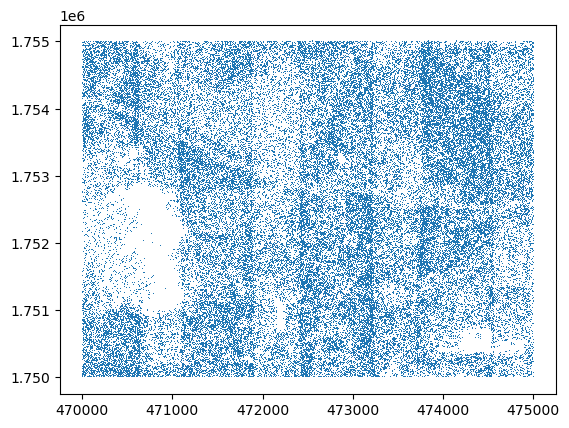

In [4]:
plt.plot(xyz[::1000,0], xyz[::1000,1], ',')

### Convert numpy array to Open3D point cloud  

Downsample before creating the Open3D point cloud when memory is not enough

In [11]:
step = 1  # Increase this value for larger files (try 100 if still too big)
xyz = np.vstack((pc1.x[::step], pc1.y[::step], pc1.z[::step])).transpose()
print('Loaded %d points' % xyz.shape[0])

Loaded 79850358 points


In [12]:
# Pass xyz to Open3D.o3d.geometry.PointCloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(xyz)
print('pcd:', pcd)

pcd: PointCloud with 79850358 points.


Get colors function

In [ ]:
# Define function to map values to colors
def get_colors(inp, colormap, vmin=None, vmax=None):
    if vmin == None:
        vmin=np.nanmin(inp)
    if vmax == None:
        vmax=np.nanmax(inp)
    norm = plt.Normalize(vmin, vmax)
    return colormap(norm(inp))

# Apply colormap based on height (z value)
rgb = get_colors(np.asarray(pcd.points)[:,2], plt.cm.viridis, # try plt.cm.terrain or plt.cm.viridis
                 vmin=np.percentile(np.asarray(pcd.points)[:,2],2), 
                 vmax=np.percentile(np.asarray(pcd.points)[:,2],98))
pcd.colors = o3d.utility.Vector3dVector(rgb[:,0:3])

In [16]:
o3d.visualization.draw_geometries([pcd])

[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.
